In [9]:
import pandas 
import numpy as np
import moments 
import dpluspy 
import scipy
import demes
import matplotlib
import matplotlib.pylab as plt

matplotlib.rc("xtick", labelsize=16)
matplotlib.rc("ytick", labelsize=16)
matplotlib.rc("axes", labelsize=16)
matplotlib.rc("axes", titlesize=16)
matplotlib.rc("legend", fontsize=16)

matplotlib.rc('axes', linewidth=1.5)

In [15]:
# create models 

rs = np.logspace(-6, -2, 48)
u = 1e-8

# equlibrium model
b0 = demes.Builder()
b0.add_deme("X", epochs=[{"start_size": 1e4, "end_time": 0}])
g0 = b0.resolve()
y0 = moments.Demes.LD(g0, sampled_demes=["X"], r=rs, u=u)
Dp0 = y0.H2(0)
ratio0 = Dp0 / y0.H()[0] ** 2

# growth model
b1 = demes.Builder()
b1.add_deme("X", epochs=[
    {"start_size": 1e4, "end_time": 1e5},
    {"start_size": 2e4, "end_time": 0}])
g1 = b1.resolve()
y1 = moments.Demes.LD(g1, sampled_demes=["X"], r=rs, u=u)
Dp1 = y1.H2(0)
ratio1 = Dp1 / y1.H()[0] ** 2

# contraction model
b2 = demes.Builder()
b2.add_deme("X", epochs=[
    {"start_size": 1e4, "end_time": 1e4},
    {"start_size": 5e3, "end_time": 0}])
g2 = b2.resolve()
y2 = moments.Demes.LD(g2, sampled_demes=["X"], r=rs, u=u)
Dp2 = y2.H2(0)
ratio2 = Dp2 / y2.H()[0] ** 2

# admixture model
b3 = demes.Builder()
b3.add_deme("X", epochs=[{"start_size": 1e4, "end_time": 0}])
b3.add_deme("Y", start_time=2e4, epochs=[{"start_size": 1e3, "end_time": 0}],
    ancestors=["X"])
b3.add_pulse(sources=["Y"], dest="X", proportions=[0.10], time=500)
g3 = b3.resolve()
y3 = moments.Demes.LD(g3, sampled_demes=["X"], r=rs, u=u)
Dp3 = y3.H2(0)
ratio3 = Dp3 / y3.H()[0] ** 2

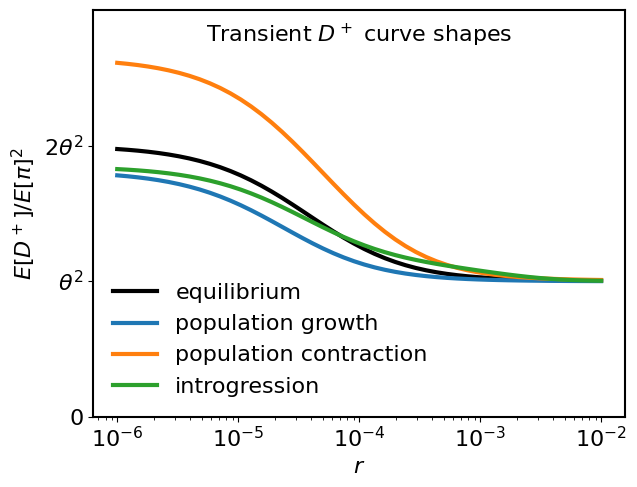

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 5), layout="tight", linewidth=4)

width = 3

ax.plot(rs, ratio0, color="black", linewidth=width, label="equilibrium")
ax.plot(rs, ratio1, color="tab:blue", linewidth=width, label="population growth")
ax.plot(rs, ratio2, color="tab:orange", linewidth=width, label="population contraction")
ax.plot(rs, ratio3, color="tab:green", linewidth=width, label="introgression")

ax.set_title("Transient $D^+$ curve shapes", x=0.50, y=0.90)
ax.set_xscale("log")
ax.legend(framealpha=0, loc="lower left")
ax.set_yticks([0, 1, 2], labels=["$0$", r"$\theta^2$", r"$2\theta^2$"])
ax.set_ylim(0, 3)
ax.set_ylabel(r"$E[D^+] / E[\pi]^2$")
ax.set_xlabel("$r$")
plt.savefig("poster_curves_figure.svg")